In [69]:
import sys
sys.path.insert(0, '.')
sys.path.insert(1, '..')
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit
from utils import *
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F

In [ ]:
preds_dir = '/home/bela/thesis/preds_DDIM/'
dataset_dir = '../../data/all_years_merged_era5.nc'
dataset_dir2 = '../../data/era5_3h_merged.nc'
preds_dir2 = '/home/bela/thesis/preds_DDIM_3h/'
preds_dir_edsr = '/home/bela/thesis/preds/'
SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)
years2 = [i for i in range(1984, 2024)]


XYFONTSIZE = 16
LEGEND_TICK_FONTSIZE = 14

[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [94]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [95]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)
eval_split2, ground_truth_wind_speeds2, scale2 = get_ground_truth_ws(data_dir=dataset_dir2,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)

In [96]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

def downsampling(xarray, factor):
    return xarray.isel(latitude=slice(0, None, factor), longitude=slice(0, None, factor))
lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)

def get_low_res_ws2(test_data, scaling_factor):
    u10 = downsampling(test_data['u10'], scaling_factor).values
    v10 = downsampling(test_data['v10'], scaling_factor).values
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws
lr_wind_speeds2 = get_low_res_ws2(eval_split2, SCALING_FACTOR)

In [97]:
#preds_DDIM_1984_4.pt

In [98]:
def get_edsr_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale):
    files = os.listdir(files_dir)
    ws_fields = []
    names = []
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
            
        #print("Current file: ", file)   
        
        if file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names



In [99]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        
        
        
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False, map_location=torch.device('cpu'))
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            print(baseline.shape)
            
        elif file == f'preds_DDIM_{year}_{scaling_factor}.pt':
            field = torch.load(files_dir + file, weights_only=False, map_location=torch.device('cpu'))
            field = field.squeeze(1)
            
            names.append("DDIM")
            ws_field = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(ws_field)
            print(ws_field.shape)
    return ws_fields, names


In [100]:
longitudes = eval_split2.longitude.values[:32]
latitudes = eval_split2.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


In [101]:
ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)

ws_fields2, names2 = get_wind_speed_fields(files_dir=preds_dir2,
                                        scaling_factor=SCALING_FACTOR,
                                        year=TEST_YEAR,
                                        normalization_scale=scale2,
                                        lr_ws=lr_wind_speeds2,
                                        gt_ws=ground_truth_wind_speeds2)
edsr_ws, edsr_names = get_edsr_wind_speed_fields(preds_dir_edsr, SCALING_FACTOR, TEST_YEAR, scale)

print(len(ws_fields), len(names))
print(len(ws_fields2), len(names2))
print(len(edsr_ws), len(edsr_names))

torch.Size([1464, 32, 32])
torch.Size([2928, 32, 32])
3 3
3 3
1 1


In [102]:
ddim = ws_fields[names.index("DDIM")]
hr_gt = ws_fields[names.index("HR Ground Truth")]  

ValueError: 'DDIM' is not in list

In [103]:

hr_gt = hr_gt[1:-5]
print(len(hr_gt), len(ddim))

1452 2920


In [81]:
ws_fields2.insert(2, edsr_ws[0])
names2.insert(2, "EDSR")

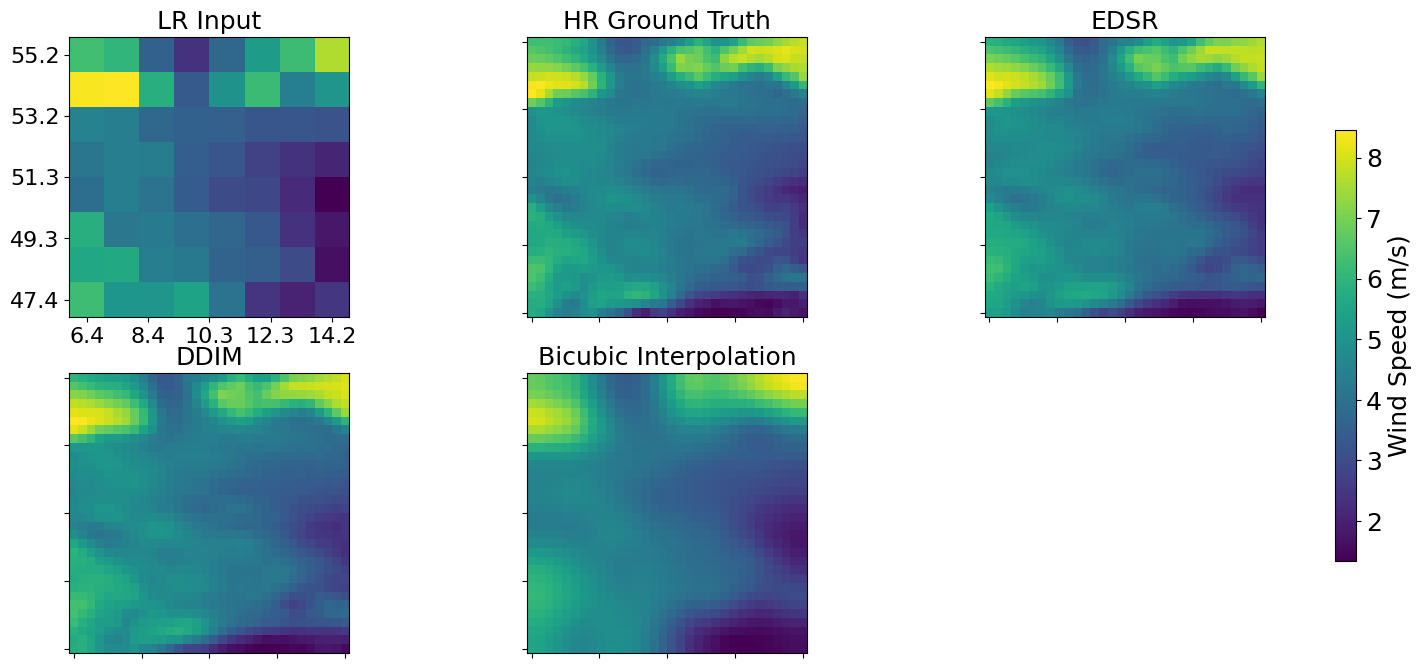

In [82]:

def plot_comparison(fields, names, index):
    assert index % 4 == 0
    assert len(fields) == len(names)
    
    rows, cols = 2, 3
    fig, ax = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    
    selected_fields = []
    for i, field in enumerate(fields):
        if names[i] == "EDSR":
            selected_fields.append(field[index//2])
        else:
            selected_fields.append(field[index])
    
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)

    title_fontsize = 18
    axis_label_fontsize = 22
    tick_label_fontsize = 16
    colorbar_label_fontsize = 18
    colorbar_tick_fontsize = 18

    ax = ax.flatten()

    for i, field in enumerate(selected_fields):
        im = ax[i].imshow(field, cmap='viridis')
        ax[i].set_title(names[i], fontsize=title_fontsize)
        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        if i  == 0: 
            ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks], fontsize=tick_label_fontsize)
            ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks], fontsize=tick_label_fontsize)
        else:
            ax[i].set_xticklabels([])
            ax[i].set_yticklabels([])

    if len(selected_fields) < rows * cols:
        fig.delaxes(ax[-1])

    cbar = fig.colorbar(im, ax=ax[:-1], orientation='vertical', fraction=0.02, pad=0.05, shrink=0.7)
    cbar.set_label('Wind Speed (m/s)', fontsize=colorbar_label_fontsize)

    for a in ax[:len(selected_fields)]:
        a.tick_params(axis='both', labelsize=tick_label_fontsize)
    for ca in cbar.ax.yaxis.get_ticklabels():
        ca.set_fontsize(colorbar_tick_fontsize)

    plt.savefig(f"../../plots/ddim_edsr_comparison_{index}.pdf", bbox_inches='tight')
    plt.show()
plot_comparison(ws_fields2, names2, 440)

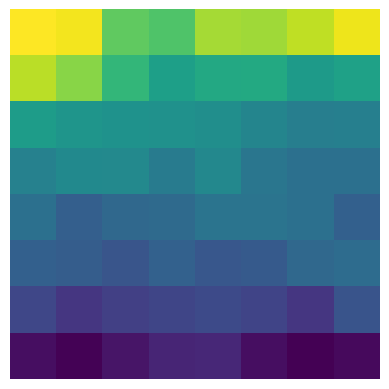

In [83]:
plt.imshow(lr_wind_speeds[0], cmap='viridis')
#turn off axis
plt.axis('off')
plt.savefig('../../plots/lr_example.png', transparent=True, bbox_inches='tight')
plt.show()


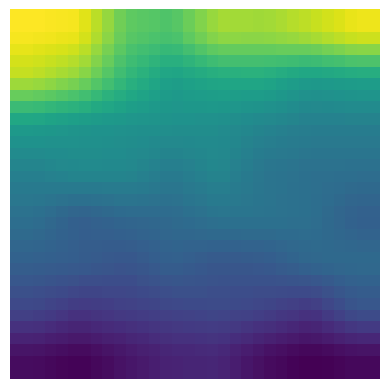

In [84]:
bilinear_interpolation = F.interpolate(torch.tensor(lr_wind_speeds[0]).unsqueeze(0).unsqueeze(0), scale_factor=4, mode='bilinear')
bilinear_interpolation = bilinear_interpolation.squeeze(0).squeeze(0).numpy()
plt.imshow(bilinear_interpolation, cmap='viridis')
plt.axis('off')
plt.savefig('../../plots/bilinear_example.png', transparent=True, bbox_inches='tight')

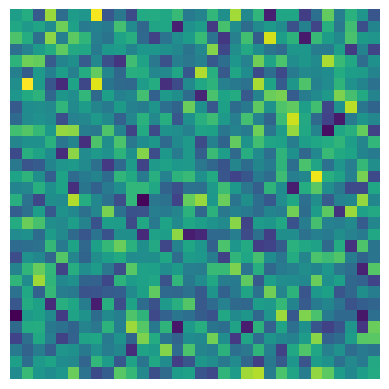

In [85]:
import numpy as np
random_noise = np.random.normal(0, 1, size=(32, 32))
plt.imshow(random_noise, cmap='viridis')
plt.axis('off')
plt.savefig('../../plots/random_noise_example.png', transparent=True, bbox_inches='tight')

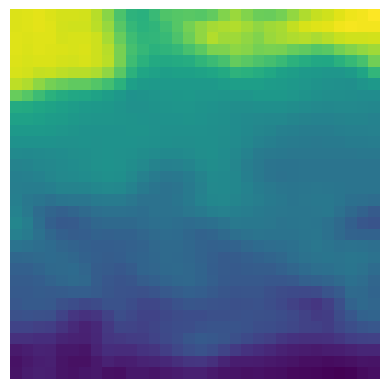

In [86]:
ddim = ws_fields2[names2.index("DDIM")]
plt.imshow(ddim[0], cmap='viridis')
plt.axis('off')
#remove whitepsace
plt.savefig('../../plots/ddim_example.png',transparent=True, bbox_inches='tight')


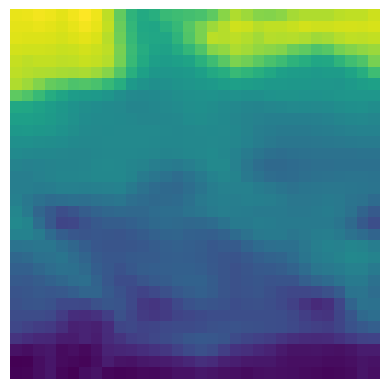

In [87]:
plt.imshow(hr_gt[0], cmap='viridis')
plt.axis('off')
plt.savefig('../../plots/hr_example.png',transparent=True, bbox_inches='tight')

In [88]:
ws_dict2 = {year: {} for year in years2}
ws_dict_6h = {year: {} for year in years2}

for year in years2:
        print(f"Processing year {year}")    
        eval_split, ground_truth_wind_speeds_3h, scale = get_ground_truth_ws(data_dir=dataset_dir2,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        lr_wind_speeds2 = get_low_res_ws2(eval_split, SCALING_FACTOR)
        ws_fields2, names2 = get_wind_speed_fields(files_dir=preds_dir2, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds2, 
                                                gt_ws=ground_truth_wind_speeds2)
        
        _, ground_truth_wind_speeds_6h, scale_6h = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        edsr_field = get_edsr_wind_speed_fields(preds_dir_edsr, SCALING_FACTOR, year, scale_6h)
        ddim = ws_fields2[names2.index('DDIM')]
        baseline = ws_fields2[names2.index('Bicubic Interpolation')]
        ws_dict2[year]['DDIM'] = ddim
        ws_dict2[year]['Baseline'] = baseline
        ws_dict2[year]['Ground Truth'] = ground_truth_wind_speeds_3h
        ws_dict_6h[year]['EDSR'] = edsr_field[0]
        ws_dict_6h[year]['Ground Truth'] = ground_truth_wind_speeds_6h
        
        

Processing year 1984
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1985
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1986
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1987
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1988
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1989
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1990
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1991
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1992
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1993
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1994
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1995
torch.Size([2920, 32, 32])
torch.Size([2920, 32, 32])
Processing year 1996
torch.Size([2928, 32, 32])
torch.Size([2928, 32, 32])
Processing year 1997
torc

In [89]:
def get_metrics_over_time(years):
    mses = {'DDIM': [], 'Bicubic': [], 'EDSR': []}
    maes = {'DDIM': [], 'Bicubic': [], 'EDSR': []}
    mse_skill_scores = {'DDIM': [], 'EDSR': []}
    mae_skill_scores = {'DDIM': [], 'EDSR': []}
    for year in years:
        print(f"Processing year {year}")
    
        ddim, baseline = ws_dict2[year]['DDIM'], ws_dict2[year]['Baseline']
        ground_truth_wind_speeds_3h = ws_dict2[year]['Ground Truth']
        edsr, ground_truth_wind_speeds_6h = ws_dict_6h[year]['EDSR'], ws_dict_6h[year]['Ground Truth']
        mse_ddim, mae_ddim = get_metrics(ddim, ground_truth_wind_speeds_3h)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds_3h)
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds_6h)
        
        
        mses['DDIM'].append(mse_ddim)
        mses['Bicubic'].append(mse_baseline)
        maes['DDIM'].append(mae_ddim)
        maes['Bicubic'].append(mae_baseline)
        mses['EDSR'].append(mse_edsr)
        maes['EDSR'].append(mae_edsr)
        mse_skill_scores['DDIM'].append(get_skill_score(mse_ddim, mse_baseline))
        mae_skill_scores['DDIM'].append(get_skill_score(mae_ddim, mae_baseline))
        mse_skill_scores['EDSR'].append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores['EDSR'].append(get_skill_score(mae_edsr, mae_baseline))
    return mses, maes, mse_skill_scores, mae_skill_scores

    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    ax[0].plot(years, mse_ss, label='MSE Skill Score', color='darkgreen')
    ax[0].set_xlabel('Year', fontsize=XYFONTSIZE)
    ax[0].set_ylabel('Skill Score', fontsize=XYFONTSIZE)
    ax[0].legend(fontsize=LEGEND_TICK_FONTSIZE)
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, label='MAE Skill Score', color='darkgoldenrod')
    ax[1].set_xlabel('Year', fontsize=XYFONTSIZE)
    ax[1].set_ylabel('Skill Score', fontsize=XYFONTSIZE)
    ax[1].legend(fontsize=LEGEND_TICK_FONTSIZE)
    ax[1].grid(True)

    for a in ax:
        a.tick_params(axis='both', labelsize=LEGEND_TICK_FONTSIZE)
    plt.tight_layout()
    plt.show()

def plot_metrics(years, mse_a, mse_b, mae_a, mae_b, label_a, label_b):
    fig, ax = plt.subplots(2,1, figsize=(10,7))

    ax[0].plot(years, mse_a, label=label_a, color='midnightblue')
    ax[0].plot(years, mse_b, label=label_b, color='lightsteelblue')
    ax[0].set_xlabel('Year', fontsize=14)
    ax[0].set_ylabel('MSE', fontsize=14)
    ax[0].legend(fontsize=12)

    ax[1].plot(years, mae_a, label=label_a, color='darkred')
    ax[1].plot(years, mae_b, label=label_b, color='lightcoral')
    ax[1].set_xlabel('Year', fontsize=14)
    ax[1].set_ylabel('MAE', fontsize=14)
    ax[1].legend(fontsize=12)
    for a in ax:
        a.tick_params(axis='both', labelsize=12)
    plt.savefig(f"../../plots/metrics_{label_a}_{label_b}.pdf", bbox_inches='tight')
    plt.show()

In [90]:
mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

Processing year 1984
Processing year 1985
Processing year 1986
Processing year 1987
Processing year 1988
Processing year 1989
Processing year 1990
Processing year 1991
Processing year 1992
Processing year 1993
Processing year 1994
Processing year 1995
Processing year 1996
Processing year 1997
Processing year 1998
Processing year 1999
Processing year 2000
Processing year 2001
Processing year 2002
Processing year 2003
Processing year 2004
Processing year 2005
Processing year 2006
Processing year 2007
Processing year 2008
Processing year 2009
Processing year 2010
Processing year 2011
Processing year 2012
Processing year 2013
Processing year 2014
Processing year 2015
Processing year 2016
Processing year 2017
Processing year 2018
Processing year 2019
Processing year 2020
Processing year 2021
Processing year 2022
Processing year 2023


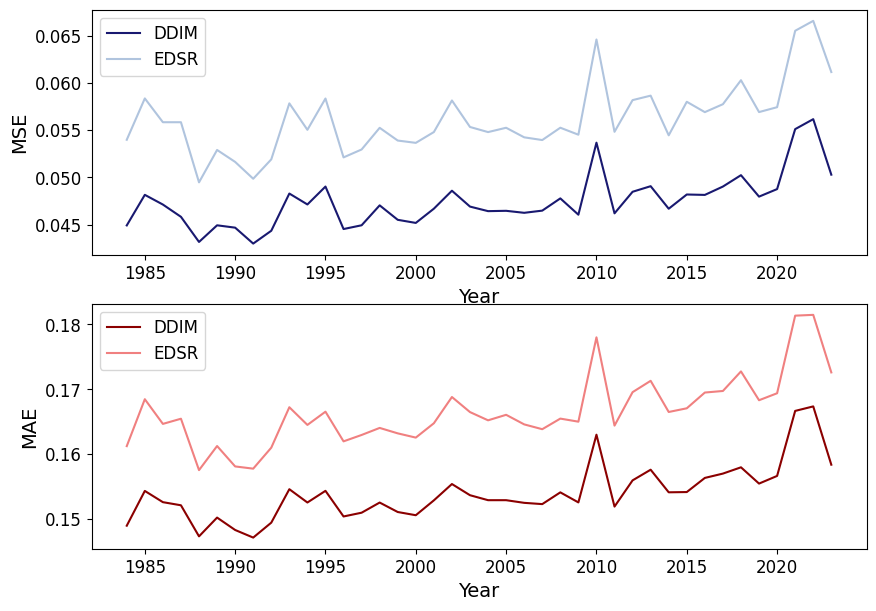

In [91]:
plot_metrics(years, mses['DDIM'],mses["EDSR"], maes['DDIM'], maes["EDSR"], "DDIM", "EDSR")

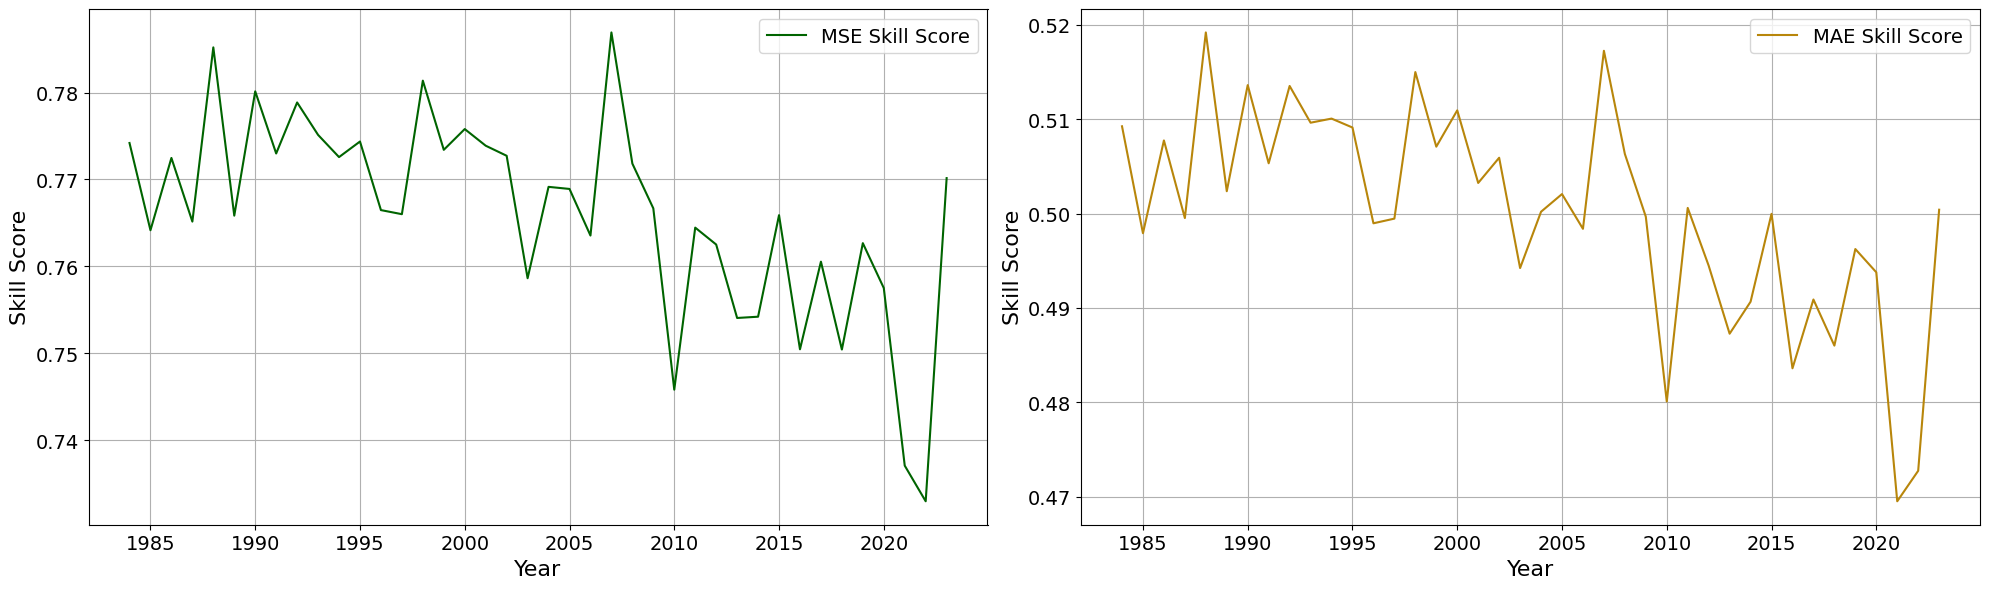

In [92]:
plot_skill_scores(years, mse_skill_scores['DDIM'], mae_skill_scores['DDIM'])